In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [ ]:
!pip install scikit-learn

In [4]:
iris = load_iris()
print(type(iris))

<class 'sklearn.utils._bunch.Bunch'>


In [6]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [12]:
iris.data.shape

(150, 4)

In [16]:
iris.target.shape

(150,)

In [18]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [21]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [22]:
iris.filename

'iris.csv'

In [23]:
iris.data_module

'sklearn.datasets.data'

In [20]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [28]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [30]:
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [36]:
df['target_name'] = df.target.map({0:'setosa', 1:'versicolor', 2:'virginica'})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [37]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
target_name          0
dtype: int64

In [40]:
df['target_name'].value_counts()

target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [41]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [42]:
df.shape

(150, 6)

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   target_name        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [44]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [45]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [46]:
x = df.drop(columns=['target', 'target_name'])
x.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [47]:
y = df['target']
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [50]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [51]:
x_train.shape, x_test.shape

((120, 4), (30, 4))

In [52]:
y_train.shape, y_test.shape

((120,), (30,))

In [60]:
from sklearn.tree import DecisionTreeClassifier

In [64]:
model = DecisionTreeClassifier(max_depth = 3, random_state=42)

In [65]:
model.fit(x_train, y_train)

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

DecisionTreeClassifier(max_depth=3, random_state=42)

In [66]:
print(model)

DecisionTreeClassifier(max_depth=3, random_state=42)


In [67]:
model.predict(x_train[:5])

array([0, 2, 1, 0, 1])

In [68]:
model.fit(x_train, y_train)

print("학습 완료")


학습 완료


In [69]:
import sklearn
import sys

print(sklearn.__version__)
print(sys.version)

1.9.0
3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]


In [70]:
from sklearn import set_config

set_config(display="text")

In [71]:
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [76]:
y_pred = model.predict(x_test)
y_pred

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 2, 2, 2, 1, 0, 2, 0])

In [84]:
from sklearn.metrics import accuracy_score

In [85]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9666666666666667

In [87]:
(y_test == y_pred).sum() / len(y_test)

np.float64(0.9666666666666667)

In [88]:
from sklearn.metrics import confusion_matrix, classification_report

In [89]:
confusion_matrix(y_test, y_pred)

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  0, 10]])

In [91]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [128]:
model.predict(x_test)

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 2, 2, 2, 1, 0, 2, 0])

In [136]:
print(model.predict_proba(x_test)[:,1])

[0.         0.         1.         1.         0.         1.
 0.         0.         0.         1.         0.         0.
 0.         1.         0.         0.         0.         1.
 1.         0.33333333 0.         0.         1.         0.25
 0.         0.         1.         0.         0.         0.        ]


In [139]:
model.predict_proba(x_test)

array([[1.        , 0.        , 0.        ],
       [0.        , 0.        , 1.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [0.        , 0.        , 1.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 0.        , 1.        ],
       [0.        , 0.        , 1.        ],
       [0.        , 0.        , 1.        ],
       [0.        , 1.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 0.33333333, 0.66666667],
       [1.        , 0.        , 0.        ],
       [0.        , 0.        , 1.        ],
       [0.

In [140]:
print(model.classes_)

[0 1 2]


In [141]:
from sklearn.tree import export_text

print(export_text(model, feature_names=list(x_train.columns)))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



In [92]:
from sklearn.cluster import KMeans

In [93]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [95]:
x = df.drop(columns=['target', 'target_name'])
x.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [96]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

In [97]:
kmeans.fit(x)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [100]:
cluster = kmeans.predict(x)
cluster

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [106]:
df['cluster'] = cluster
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name,cluster
0,5.1,3.5,1.4,0.2,0,setosa,1
1,4.9,3.0,1.4,0.2,0,setosa,1
2,4.7,3.2,1.3,0.2,0,setosa,1
3,4.6,3.1,1.5,0.2,0,setosa,1
4,5.0,3.6,1.4,0.2,0,setosa,1


In [108]:
(df['target'] == df['cluster']).sum()

np.int64(36)

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

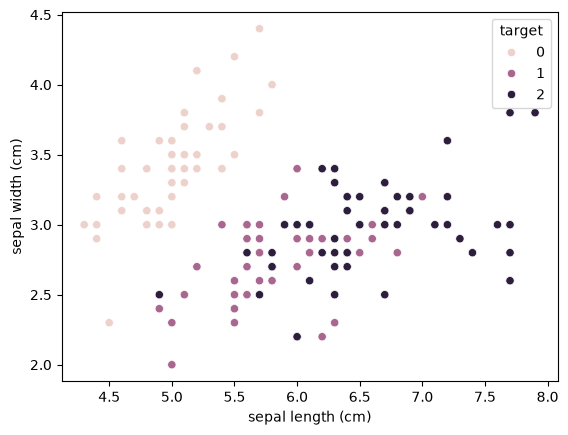

In [118]:
sns.scatterplot(df, x='sepal length (cm)', y='sepal width (cm)', hue='target')

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

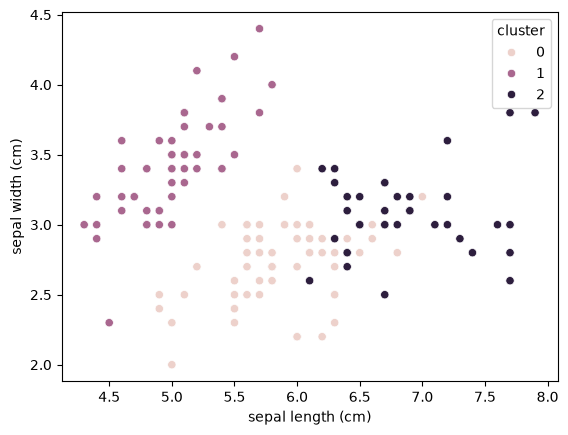

In [116]:
sns.scatterplot(df, x='sepal length (cm)', y='sepal width (cm)', hue='cluster')

In [119]:
pd.crosstab(df["target"], df["cluster"])

cluster,0,1,2
target,,,
0,0,50,0
1,48,0,2
2,14,0,36


In [121]:
df['new_cluster'] = df['cluster'].map({0:1, 1:0, 2:2})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name,cluster,new_cluster
0,5.1,3.5,1.4,0.2,0,setosa,1,0
1,4.9,3.0,1.4,0.2,0,setosa,1,0
2,4.7,3.2,1.3,0.2,0,setosa,1,0
3,4.6,3.1,1.5,0.2,0,setosa,1,0
4,5.0,3.6,1.4,0.2,0,setosa,1,0


In [125]:
accuracy_score(df['target'], df['cluster'])

0.24

In [126]:
accuracy_score(df['target'], df['new_cluster'])

0.8933333333333333

혼동행렬
[[89  1]
 [ 4 49]]

TN, FP, FN, TP
89 1 4 49

평가 지표
Accuracy: 0.965034965034965
Precision: 0.98
Recall: 0.9245283018867925
Specificity: 0.9888888888888889
F1-score: 0.9514563106796117
ROC-AUC: 0.9962264150943396

분류 보고서
              precision    recall  f1-score   support

      benign       0.96      0.99      0.97        90
   malignant       0.98      0.92      0.95        53

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143


임계값별 결과
   threshold  precision    recall        f1
0        0.3   0.980769  0.962264  0.971429
1        0.5   0.980000  0.924528  0.951456
2        0.8   1.000000  0.867925  0.929293


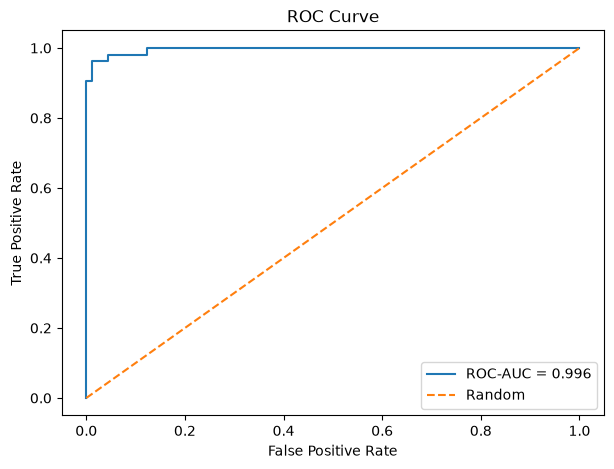


교차검증 결과
   accuracy  precision    recall        f1   roc_auc
0  0.973684   0.954545  0.976744  0.965517  0.995087
1  0.947368   1.000000  0.860465  0.925000  0.997707
2  0.964912   1.000000  0.904762  0.950000  0.985119
3  0.991228   0.976744  1.000000  0.988235  1.000000
4  0.991150   1.000000  0.976190  0.987952  0.998659

교차검증 평균
accuracy     0.973669
precision    0.986258
recall       0.943632
f1           0.963341
roc_auc      0.995314
dtype: float64

교차검증 표준편차
accuracy     0.018590
precision    0.020388
recall       0.058655
f1           0.026824
roc_auc      0.005976
dtype: float64


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score,
    roc_curve
)


# 1. 데이터 불러오기
cancer = load_breast_cancer()

X = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

original_y = pd.Series(
    cancer.target,
    name="original_target"
)


# 2. 목표변수 변환
# 1 = malignant, 악성
# 0 = benign, 양성
y = (original_y == 0).astype(int)
y.name = "malignant"


# 3. 학습·평가 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


# 4. 파이프라인 생성
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])


# 5. 학습
model.fit(X_train, y_train)


# 6. 예측 클래스 및 확률
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


# 7. 혼동행렬
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("혼동행렬")
print(cm)

print("\nTN, FP, FN, TP")
print(tn, fp, fn, tp)


# 8. 평가 지표
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
specificity = tn / (tn + fp)
auc = roc_auc_score(y_test, y_prob)

print("\n평가 지표")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)
print("F1-score:", f1)
print("ROC-AUC:", auc)


# 9. 분류 보고서
print("\n분류 보고서")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["benign", "malignant"]
    )
)


# 10. 임계값 비교
threshold_results = []

for threshold in [0.3, 0.5, 0.8]:
    pred = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            pred,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

print("\n임계값별 결과")
print(threshold_df)


# 11. ROC 곡선
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# 12. 층화 교차검증
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_result = cross_validate(
    model,
    X,
    y,
    cv=skf,
    scoring=scoring
)

cv_df = pd.DataFrame({
    "accuracy": cv_result["test_accuracy"],
    "precision": cv_result["test_precision"],
    "recall": cv_result["test_recall"],
    "f1": cv_result["test_f1"],
    "roc_auc": cv_result["test_roc_auc"]
})

print("\n교차검증 결과")
print(cv_df)

print("\n교차검증 평균")
print(cv_df.mean())

print("\n교차검증 표준편차")
print(cv_df.std())

In [3]:
np.exp(0.693)

np.float64(1.9997056605411638)